## ==============================================================================
## AI-Driven Downlink Optimization in Optical Earth Observation Missions
Master Thesis — Mirko Ponzanelli

**Objective:** SO5 — Onboard Deployment Assessment. Characterize model compression effects on U-Net Light (Strategy A)
for onboard satellite deployment.

Pipeline: Post-Training Quantization (INT8) -> Quantization-Aware Training -> Pruning

**Reference architecture:** U-Net Light (ca.1.95M params, 7.82 MB FP32)
trained with BCE on CloudSEN12+ (all 13 Sentinel-2 bands).
## =========================================================================


# 1. Google Colab Setup

In [1]:
# =====================================================================
# Colab: GPU check + dependencies
# =====================================================================
!nvidia-smi --query-gpu=name,memory.total --format=csv,noheader
!pip install -q huggingface_hub

# =====================================================================
# Download CloudSEN12+ (high quality, L1C bands + labels only)
# =====================================================================
from pathlib import Path
from huggingface_hub import snapshot_download

DATA_DIR = Path("/content/cloudsen12_high")

# Download
print("Ensuring CloudSEN12+ dataset is available (c.a. 70 GB)...")

snapshot_download(
    repo_id="csaybar/CloudSEN12-high",
    repo_type="dataset",
    allow_patterns=["*/L1C_*.dat", "*manual_hq*"],
    local_dir=str(DATA_DIR),
)

print("Dataset ready!")

# Verify
for split in ["train", "val", "test"]:
    path = DATA_DIR / split
    n = len(list(path.glob("*.dat")))
    print(f"{split}: {n} files")

!df -h /content


NVIDIA L4, 23034 MiB
Ensuring CloudSEN12+ dataset is available (c.a. 70 GB)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 42 files:   0%|          | 0/42 [00:00<?, ?it/s]

Dataset ready!
train: 14 files
val: 14 files
test: 14 files
Filesystem      Size  Used Avail Use% Mounted on
overlay         236G  114G  123G  48% /


# 2. Google Drive Setup

In [2]:
# =====================================================================
# Mount Google Drive and define output directory
# =====================================================================
from google.colab import drive
drive.mount('/content/drive')

DRIVE_PROJECT = Path("/content/drive/MyDrive/TFM/UNet_Light_CloudSEN12_B16")
RUN_DIR = DRIVE_PROJECT / "runs_v1"
SO5_DIR = DRIVE_PROJECT / "so5a_deployment_v1_1"
SO5_DIR.mkdir(parents=True, exist_ok=True)

print(f"Trained models: {RUN_DIR}")
print(f"SO5 results:    {SO5_DIR}")
!df -h /content/drive

Mounted at /content/drive
Trained models: /content/drive/MyDrive/TFM/UNet_Light_CloudSEN12_B16/runs_v1
SO5 results:    /content/drive/MyDrive/TFM/UNet_Light_CloudSEN12_B16/so5a_deployment_v1_1
Filesystem      Size  Used Avail Use% Mounted on
drive           100G   39G   62G  39% /content/drive


# 3. Environment Setup

In [3]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_XLA_FLAGS"] = "--tf_xla_enable_xla_devices=false"

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
import gc

print(f"TensorFlow: {tf.__version__}")

gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus)
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Memory growth: ON")
    except Exception as e:
        print("Could not set memory growth:", e)

# install TF Model Optimization Toolkit for QAT and pruning
!pip install -q tensorflow-model-optimization
import tensorflow_model_optimization as tfmot
print(f"TF Model Optimization: {tfmot.__version__}")

TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Memory growth: ON
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.7/242.7 kB 24.1 MB/s eta 0:00:00
TF Model Optimization: 0.8.1


# 4. Dataset Configuration

In [4]:
#====================================
# Configuration
#====================================
DATA_ROOT = Path("/content/cloudsen12_high")

TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR   = DATA_ROOT / "val"
TEST_DIR  = DATA_ROOT / "test"

# dataset parameters
NUM_S2_BANDS = 13        # Sentinel-2 bands (bands are from VNIR to SWIR 1-13 in the GeoTIFF)
IGNORE_LABEL = 99        # no-data label in CloudSEN12
TARGET_SIZE = 512        # Patch size (H, W)
ORIGINAL_SIZE = 509       # Original CloudSEN12+ p509 patch size
BATCH_SIZE = 16           # Batch size (bigger in colab)
DIVISOR = 10000.0        # Sentinel-2 L1C reflectance scaling factor

# Label mapping: CloudSEN12 classes to binary
# 0: Clear is 0 (transmit)
# 1: Thick cloud is 1 (discard)
# 2: Thin cloud is 1 (discard)
# 3: Cloud shadow is 0 (transmit , they have still information )
CLOUD_CLASSES = {1, 2}   # classes mapped to "cloud" (positive class)
# Split sizes (CloudSEN12+ high quality, p509 padded to 512)
SPLIT_SIZES = {"train": 8490, "val": 535, "test": 975}

print(f"DATA_ROOT: {DATA_ROOT}")
print(f"RUN_DIR:    {RUN_DIR}")
for d in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    print(f"  {d.name}: exists={d.exists()}")

DATA_ROOT: /content/cloudsen12_high
RUN_DIR:    /content/drive/MyDrive/TFM/UNet_Light_CloudSEN12_B16/runs_v1
  train: exists=True
  val: exists=True
  test: exists=True


# 5. Data Pipeline

In [5]:
# =====================================================================
# Memmap-based data pipeline for HuggingFace CloudSEN12-high
# =====================================================================
# Each band is a separate memmap file (int16), labels in
# LABEL_manual_hq.dat (int8). Band order: B1…B8, B8A, B9…B12.
# Images are pre-padded 509 -> 512 with zeros; we restore IGNORE_LABEL.
# =====================================================================

L1C_BAND_FILES = [
    "L1C_B1.dat", "L1C_B2.dat", "L1C_B3.dat", "L1C_B4.dat",
    "L1C_B5.dat", "L1C_B6.dat", "L1C_B7.dat", "L1C_B8.dat",
    "L1C_B8A.dat", "L1C_B9.dat", "L1C_B10.dat", "L1C_B11.dat",
    "L1C_B12.dat",
]


def load_memmap_split(split_dir):
    """Open memmap arrays for all 13 L1C bands + label."""
    split_name = Path(split_dir).name
    n = SPLIT_SIZES[split_name]
    shape = (n, TARGET_SIZE, TARGET_SIZE)

    bands = []
    for fname in L1C_BAND_FILES:
        fpath = Path(split_dir) / fname
        bands.append(np.memmap(str(fpath), dtype="int16", mode="r", shape=shape))

    label = np.memmap(
        str(Path(split_dir) / "LABEL_manual_hq.dat"), dtype="int8", mode="r", shape=shape
    )
    return bands, label, n


def make_dataset(split_dir, batch_size=BATCH_SIZE, shuffle=True, augment=False):
    """Create a tf.data.Dataset from memmap arrays.

    Zero-padded pixels (all 13 bands == 0) are marked IGNORE_LABEL
    so they are excluded from loss and all metrics.

    Output:
      x : float32 (512, 512, 13)  normalized reflectance [0, 1]
      y : float32 (512, 512, 1)   binary mask {0, 1, 99}
    """
    bands, label, n_samples = load_memmap_split(split_dir)
    split_name = Path(split_dir).name
    print(f"  {split_name}: {n_samples} samples ({len(bands)} bands)")

    def generator():
        indices = list(range(n_samples))
        if shuffle:
            np.random.shuffle(indices)

        for i in indices:

            # extract patch i from each Sentinel-2 band
            band_patches = [band[i] for band in bands]
            # stack bands into a multispectral image (H, W, 13)
            x = np.stack(band_patches, axis=-1)
            # convert to float32
            x = x.astype(np.float32)
            #  normalize reflectance
            x = x / DIVISOR
            # values between 0 and 1
            x = np.clip(x, 0.0, 1.0)

            # binary label mapping
            y = label[i].astype(np.float32)

            # convert labels to integer class codes
            y_int = y.astype(int)

            # identify pixels belonging to cloud classes
            is_cloud = np.isin(y_int, list(CLOUD_CLASSES))

            # map cloud pixels to 1.0 and all others to 0.0
            y_bin = np.where(is_cloud, 1.0, 0.0)

            # restore ignore pixels
            y_bin = np.where(y_int == IGNORE_LABEL, float(IGNORE_LABEL), y_bin)

            # Set  IGNORE_LABEL on zero-padded pixels
            # HF pads 509 -> 512 with zeros (Clear)
            # padding mark as ignore instead (IGNORE_LABEL 99)
            # A pixel with all 13 bands = 0 carries no radiometric
            # information regardless of cause
            all_zero = np.all(x == 0.0, axis=-1)
            y_bin = np.where(all_zero, float(IGNORE_LABEL), y_bin)

            yield x, y_bin[..., np.newaxis]

    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(TARGET_SIZE, TARGET_SIZE, NUM_S2_BANDS), dtype=tf.float32),
            tf.TensorSpec(shape=(TARGET_SIZE, TARGET_SIZE, 1), dtype=tf.float32),
        ),
    )

    if augment:
        ds = ds.map(_augment, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(batch_size, drop_remainder=True)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


@tf.function
def _augment(x, y):
    """Random augmentation: flips, 90° rotations, additive Gaussian noise"""
    # random horizontal flip
    if tf.random.uniform(()) > 0.5:
        x = tf.image.flip_left_right(x)
        y = tf.image.flip_left_right(y)
    # random vertical flip
    if tf.random.uniform(()) > 0.5:
        x = tf.image.flip_up_down(x)
        y = tf.image.flip_up_down(y)
    # random 90° rotation
    k = tf.random.uniform((), maxval=4, dtype=tf.int32)
    x = tf.image.rot90(x, k)
    y = tf.image.rot90(y, k)
    # additive gaussian noise
    x = x + tf.random.normal(tf.shape(x), mean=0.0, stddev=0.01)
    x = tf.clip_by_value(x, 0.0, 1.0)
    return x, y

In [6]:
print("Building datasets...")
train_ds = make_dataset(TRAIN_DIR, shuffle=True, augment=True)
val_ds   = make_dataset(VAL_DIR,   shuffle=False, augment=False)
test_ds  = make_dataset(TEST_DIR,  shuffle=False, augment=False)

# check
x_sample, y_sample = next(iter(val_ds))
print(f"\nBatch shapes: x={x_sample.shape}, y={y_sample.shape}")
print(f"x range: [{x_sample.numpy().min():.3f}, {x_sample.numpy().max():.3f}]")
print(f"y unique: {np.unique(y_sample.numpy())}")

Building datasets...
  train: 8490 samples (13 bands)
  val: 535 samples (13 bands)
  test: 975 samples (13 bands)

Batch shapes: x=(16, 512, 512, 13), y=(16, 512, 512, 1)
x range: [0.000, 1.000]
y unique: [ 0.  1. 99.]


# 6. Model Architecture — U-Net Light

Lightweight U-Net derived from the ϕ-Sat-1 CloudScout architecture (Giuffrida et al. 2022).
Architecture details are documented in the training notebook (A).
This cell defines the architecture for reference; the pre-trained weights
are loaded from Strategy A (symmetric BCE).

In [7]:
def conv_block(x, filters, dropout_rate=0.2):
    """Two Conv2D + Batch Normalization + ReLU layers with optional dropout."""
    x = tf.keras.layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    if dropout_rate > 0:
        x = tf.keras.layers.Dropout(dropout_rate)(x)

    x = tf.keras.layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    return x


def build_unet_light(input_shape=(512, 512, 13), filters=(32, 64, 128)):
    """U-Net-light for binary cloud detection.

    Parameters
    ----------
    input_shape : tuple
        (H, W, C)  all 13 Sentinel-2 bands.
    filters : tuple
        Number of filters per encoder level.

    Returns
    -------
    tf.keras.Model with sigmoid output (H, W, 1).
    """
    inp = tf.keras.Input(shape=input_shape, name="sentinel2_input")

    #  Encoder
    skips = []
    x = inp
    for f in filters:
        x = conv_block(x, f)
        skips.append(x)
        x = tf.keras.layers.MaxPooling2D(2)(x)

    # Bottleneck
    x = conv_block(x, filters[-1] * 2)

    # Decoder
    for f, skip in zip(reversed(filters), reversed(skips)):
        x = tf.keras.layers.UpSampling2D(2, interpolation="bilinear")(x)
        x = tf.keras.layers.Concatenate()([x, skip])
        x = conv_block(x, f)

    # output
    x = tf.keras.layers.Conv2D(1, 1, padding="same", name="logits")(x)
    out = tf.keras.layers.Activation("sigmoid", dtype="float32", name="cloud_prob")(x)

    model = tf.keras.Model(inp, out, name="UNet_light_binary")
    return model

# 7. Loss Functions and Evaluation Metrics

In [8]:
# =====================================================================
# Masked Binary Cross-Entropy — symmetric (Strategy A, C)
# =====================================================================
@tf.function
def masked_bce_symmetric(y_true, y_pred):
    """Standard BCE with masking for ignore label.

    y_true: (B, H, W, 1) float32, values in {0, 1, IGNORE_LABEL}
    y_pred: (B, H, W, 1) float32, sigmoid probabilities
    """
    # cast inputs to float32 for calculation
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # create a mask: 1 for valid pixels, 0 for IGNORE_LABEL
    mask = tf.not_equal(y_true, float(IGNORE_LABEL))
    mask_f = tf.cast(mask, tf.float32)

    # replace IGNORE_LABEL with 0 to avoid NaN in BCE
    y_safe = tf.where(mask, y_true, tf.zeros_like(y_true))

    # compute BCE (shape: B,H,W)
    bce = tf.keras.losses.binary_crossentropy(y_safe, y_pred)
    # zero out ignored pixels
    bce = bce * mask_f[:, :, :, 0]

    # return mean loss over valid pixels only
    return tf.reduce_sum(bce) / (tf.reduce_sum(mask_f) )


# =====================================================================
# Masked Weighted BCE —  asymmetric (Strategy B, D)
# =====================================================================
class MaskedWeightedBCE(tf.keras.losses.Loss):
    """Weighted BCE that penalizes FP more heavily than FN.

    False Positive (FP): clear pixel predicted as cloud i.e. good image discarded = IRREVERSIBLE DATA LOSS
    False Negative (FN): cloud pixel predicted as clear = wasted bandwidth (accetable)

    The assumption is  w_fp > w_fn to protect scientific data.

    The weight is applied based on the ground-truth label:
      y_true = 0 (clear pixel): loss weighted by w_fp
      (penalization predicting cloud when it's  clear)
    - y_true = 1 (cloud pixel): loss weighted by w_fn
      (penalization predicting clear when it's  cloud)
    """

    def __init__(self, w_fp=2.0, w_fn=1.0, name="weighted_bce"):
        super().__init__(name=name)
        self.w_fp = w_fp
        self.w_fn = w_fn

    def call(self, y_true, y_pred):
        # cast inputs to float32 for calculation
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)

        # create a mask: 1 for valid pixels, 0 for IGNORE_LABEL
        mask = tf.not_equal(y_true, float(IGNORE_LABEL))
        mask_f = tf.cast(mask, tf.float32)

        # replace IGNORE_LABEL with 0 to avoid NaN in BCE
        y_safe = tf.where(mask, y_true, tf.zeros_like(y_true))

         # compute BCE (shape: B,H,W)
        bce = tf.keras.losses.binary_crossentropy(y_safe, y_pred)

        # apply weights based on ground truth
        # y_true=0 (clear)  w_fp; y_true=1 (cloud)  w_fn
        weights = tf.where(
            tf.equal(y_safe[:, :, :, 0], 0.0),
            self.w_fp,
            self.w_fn
        )

        weighted_bce = bce * weights * mask_f[:, :, :, 0]
        return tf.reduce_sum(weighted_bce) / (tf.reduce_sum(mask_f) )

    def get_config(self):
        return {"w_fp": self.w_fp, "w_fn": self.w_fn, "name": self.name}


# =====================================================================
# Masked metrics (shared across all strategies)
# =====================================================================
@tf.function
def masked_binary_accuracy(y_true, y_pred):
    """Pixel-level accuracy ignoring IGNORE_LABEL."""
    # cast inputs to float32 for calculation
    y_true = tf.cast(y_true, tf.float32)
    # create a mask: 1 for valid pixels, 0 for IGNORE_LABEL
    mask = tf.not_equal(y_true, float(IGNORE_LABEL))
    # probability in class
    pred_class = tf.cast(y_pred >= 0.5, tf.float32)
    # check correctness
    correct = tf.logical_and(mask, tf.equal(y_true, pred_class))

    # return accuracy over valid pixels only
    return tf.reduce_sum(tf.cast(correct, tf.float32)) / (
        tf.reduce_sum(tf.cast(mask, tf.float32))
    )


@tf.function
def masked_cloud_iou(y_true, y_pred):
    """IoU (Intersection Over Union)  for cloud class (positive class = 1), ignoring IGNORE_LABEL."""
    # cast inputs to float32 for calculation and remove channel
    y_true = tf.cast(y_true[:, :, :, 0], tf.float32)
    y_pred_cls = tf.cast(y_pred[:, :, :, 0] >= 0.5, tf.float32)

    # create a mask: 1 for valid pixels, 0 for IGNORE_LABEL
    mask = tf.not_equal(y_true, float(IGNORE_LABEL))
    mask_f = tf.cast(mask, tf.float32)
    # GT and prediction w/o ignored pixels
    gt = y_true * mask_f
    pr = y_pred_cls * mask_f
    # intersection
    inter = tf.reduce_sum(gt * pr)
    #union
    union = tf.reduce_sum(gt) + tf.reduce_sum(pr) - inter
    return inter / (union + 1e-8)

# 8. Evaluation Functions

Pixel-level and tile-level evaluation pipelines, reused from the
training notebook. These functions compute confusion matrix counts
and derive standard (OA, mIoU, Kappa) and operational (FPR, Recall, F1,
Downlink Efficiency) metrics.

In [9]:
# =====================================================================
# Pixel-level evaluation — confusion matrix counts + standard metrics
# =====================================================================

def _cohens_kappa(TP, FP, TN, FN):
    """Cohen's Kappa from confusion matrix counts."""
    N = TP + FP + TN + FN
    if N == 0:
        return 0.0
    po = (TP + TN) / N                                        # observed agreement
    pe = ((TP+FP)*(TP+FN) + (TN+FN)*(TN+FP)) / (N * N)       # expected (chance)
    return (po - pe) / (1 - pe) if pe != 1.0 else 1.0


def evaluate_pixel_level(model, ds, t_pix=0.5):
    """Count TP, FP, TN, FN on all valid pixels.

    Returns raw counts, standard field metrics (OA, mIoU, Kappa),
    and operational metrics (FPR, FNR, Precision, Recall, F1).
    """
    TP = FP = TN = FN = 0
    for xb, yb in ds:
        yb   = tf.cast(yb, tf.float32)
        prob = model(xb, training=False)
        mask = tf.not_equal(yb, float(IGNORE_LABEL))
        pred = tf.cast(prob >= t_pix, tf.float32)
        m    = tf.cast(mask, tf.float32)
        y_valid = yb * m
        p_valid = pred * m

        TP += float(tf.reduce_sum(y_valid * p_valid))
        FP += float(tf.reduce_sum((1 - y_valid) * p_valid * m))
        TN += float(tf.reduce_sum((1 - y_valid) * (1 - p_valid) * m))
        FN += float(tf.reduce_sum(y_valid * (1 - p_valid) * m))

    eps = 1e-8
    cloud_iou = TP / (TP + FP + FN + eps)
    clear_iou = TN / (TN + FP + FN + eps)

    return {
        # Raw confusion matrix counts
        "TP": int(TP), "FP": int(FP), "TN": int(TN), "FN": int(FN),
        # Standard field metrics
        "OA":        (TP + TN) / (TP + FP + TN + FN + eps),
        "Cloud_IoU": cloud_iou,
        "Clear_IoU": clear_iou,
        "mIoU":      0.5 * (cloud_iou + clear_iou),
        "Kappa":     _cohens_kappa(TP, FP, TN, FN),
        # Operational metrics
        "Precision": TP / (TP + FP + eps),
        "Recall":    TP / (TP + FN + eps),
        "F1":        2*TP / (2*TP + FP + FN + eps),
        "FPR":       FP / (FP + TN + eps),
        "FNR":       FN / (FN + TP + eps),
    }


In [10]:
def evaluate_tile_level(model, ds, t_pix=0.5, t_img=0.70):
    """Classify each image as transmit/discard and count errors."""
    TP = FP = TN = FN = 0

    for xb, yb in ds:
        # cloud probability and convert to numpy
        prob = model(xb, training=False).numpy()
        # ground truth to numpy
        yb   = yb.numpy()
        # loop over images
        for i in range(prob.shape[0]):
            # image cloud probability
            p = prob[i, :, :, 0]
            # image ground truth
            y = yb[i, :, :, 0]
            # valid mask bolean
            valid = (y != IGNORE_LABEL)
            # predicted cloud fraction
            pred_cf = (p[valid] >= t_pix).mean()
            # ground truth cloud fraction
            gt_cf   = y[valid].mean()

            # prediction tile
            pred_tile = int(pred_cf >= t_img)
            # ground truth tile
            gt_tile   = int(gt_cf   >= t_img)

            if   gt_tile == 1 and pred_tile == 1: TP += 1
            elif gt_tile == 0 and pred_tile == 1: FP += 1
            elif gt_tile == 1 and pred_tile == 0: FN += 1
            else:                                 TN += 1

    eps = 1e-8
    fpr = FP / (FP + TN + eps)
    fnr = FN / (FN + TP + eps)
    de  = TP / (TP + FN + eps)        # downlink efficiency i.e. recall

    return {
        "TP": TP, "FP": FP, "TN": TN, "FN": FN,
        "FPR": fpr, "FNR": fnr, "Downlink_Efficiency": de,

    }


# 9. FP32 Baseline — Strategy A

Load the pre-trained U-Net Light from Strategy A (symmetric BCE, best checkpoint).
This serves as the reference for all compression experiments.

In [11]:
# =====================================================================
# Load Strategy A baseline and establish FP32 reference metrics
# =====================================================================
import os
os.environ["TF_USE_LEGACY_KERAS"] = "0"

BASELINE_PATH = str(RUN_DIR / "sym_bce" / "best.keras")
print(f"Loading baseline: {BASELINE_PATH}")

baseline_model = build_unet_light(input_shape=(TARGET_SIZE, TARGET_SIZE, NUM_S2_BANDS))
baseline_model.load_weights(BASELINE_PATH)

baseline_params = baseline_model.count_params()
baseline_size_mb = baseline_params * 4 / 1e6

print(f"Parameters:  {baseline_params:,}")
print(f"Model size:  {baseline_size_mb:.2f} MB (FP32)")

# FP32 baseline evaluation on test set
print("\nEvaluating FP32 baseline on TEST set...")
fp32_pix = evaluate_pixel_level(baseline_model, test_ds, t_pix=0.5)
fp32_tile = evaluate_tile_level(baseline_model, test_ds, t_pix=0.5, t_img=0.70)

print(f"  Pixel — F1={fp32_pix['F1']:.4f}  FPR={fp32_pix['FPR']:.4f}  Recall={fp32_pix['Recall']:.4f}")
print(f"  Tile  — FPR={fp32_tile['FPR']:.4f}  DL Eff={fp32_tile['Downlink_Efficiency']:.4f}")

Loading baseline: /content/drive/MyDrive/TFM/UNet_Light_CloudSEN12_B16/runs_v1/sym_bce/best.keras
Parameters:  1,953,985
Model size:  7.82 MB (FP32)

Evaluating FP32 baseline on TEST set...
  Pixel — F1=0.8869  FPR=0.0612  Recall=0.8747
  Tile  — FPR=0.0474  DL Eff=0.8557


# 10. Post-Training Quantization (PTQ) to INT8

Post-training quantization converts FP32 weights and activations to INT8, reducing model size and computational cost.
A small calibration dataset is used to estimate the activation ranges at each layer.
This process requires no retraining.


In [12]:
# =====================================================================
# Post-Training Quantization to INT8 via TFLite
# =====================================================================
N_CALIBRATION = 200

def calibration_generator():
    """Yield calibration samples from training set for PTQ."""
    count = 0
    for xb, k in train_ds:
        for i in range(xb.shape[0]):
            if count >= N_CALIBRATION:
                return
            yield [xb[i:i+1].numpy()]
            count += 1

# convert
print(f"Converting to TFLite INT8 (calibration: {N_CALIBRATION} samples)...")
converter = tf.lite.TFLiteConverter.from_keras_model(baseline_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = calibration_generator
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.float32
converter.inference_output_type = tf.float32

tflite_ptq = converter.convert()

# save
ptq_path = str(SO5_DIR / "unet_light_ptq_int8.tflite")
with open(ptq_path, "wb") as f:
    f.write(tflite_ptq)

ptq_size_mb = len(tflite_ptq) / 1e6
print(f"PTQ model saved: {ptq_path}")
print(f"PTQ model size:  {ptq_size_mb:.2f} MB (vs {baseline_size_mb:.2f} MB FP32)")
print(f"Compression:     {baseline_size_mb / ptq_size_mb:.1f}×")

Converting to TFLite INT8 (calibration: 200 samples)...


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


PTQ model saved: /content/drive/MyDrive/TFM/UNet_Light_CloudSEN12_B16/so5a_deployment_v1_1/unet_light_ptq_int8.tflite
PTQ model size:  2.00 MB (vs 7.82 MB FP32)
Compression:     3.9×


## 10.1 PTQ Evaluation on Test Set

The TFLite Interpreter runs the INT8 model image by image. Pixel-level
and tile-level metrics are computed using the same protocol as the
FP32 baseline (t_pix=0.5, t_img=0.70).

In [13]:
# =====================================================================
# TFLite inference wrapper for pixel-level and tile-level evaluation
# =====================================================================

def tflite_predict_batch(interpreter, xb):
    """Run TFLite inference on a batch, one image at a time."""
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    preds = []
    for i in range(xb.shape[0]):
        interpreter.set_tensor(input_details[0]['index'], xb[i:i+1].numpy())
        interpreter.invoke()
        pred = interpreter.get_tensor(output_details[0]['index'])
        preds.append(pred)
    return np.concatenate(preds, axis=0)


def evaluate_tflite_pixel(interpreter, ds, t_pix=0.5):
    """Pixel-level evaluation for a TFLite model."""
    TP = FP = TN = FN = 0
    for xb, yb in ds:
        prob = tflite_predict_batch(interpreter, xb)
        yb = yb.numpy()
        for i in range(prob.shape[0]):
            p = prob[i, :, :, 0]
            y = yb[i, :, :, 0]
            valid = (y != IGNORE_LABEL)
            y_v = y[valid]
            p_v = p[valid]
            pred = (p_v >= t_pix).astype(np.float32)
            gt = (y_v == 1).astype(np.float32)
            cl = (y_v == 0).astype(np.float32)
            TP += np.sum(pred * gt)
            FP += np.sum(pred * cl)
            FN += np.sum((1 - pred) * gt)
            TN += np.sum((1 - pred) * cl)

    eps = 1e-8
    cloud_iou = TP / (TP + FP + FN + eps)
    clear_iou = TN / (TN + FP + FN + eps)
    return {
        "TP": int(TP), "FP": int(FP), "TN": int(TN), "FN": int(FN),
        "OA": (TP + TN) / (TP + FP + TN + FN + eps),
        "mIoU": 0.5 * (cloud_iou + clear_iou),
        "Precision": TP / (TP + FP + eps),
        "Recall": TP / (TP + FN + eps),
        "F1": 2*TP / (2*TP + FP + FN + eps),
        "FPR": FP / (FP + TN + eps),
    }


def evaluate_tflite_tile(interpreter, ds, t_pix=0.5, t_img=0.70):
    """Tile-level evaluation for a TFLite model."""
    TP = FP = TN = FN = 0
    for xb, yb in ds:
        prob = tflite_predict_batch(interpreter, xb)
        yb = yb.numpy()
        for i in range(prob.shape[0]):
            p = prob[i, :, :, 0]
            y = yb[i, :, :, 0]
            valid = (y != IGNORE_LABEL)
            pred_cf = (p[valid] >= t_pix).mean()
            gt_cf = y[valid].mean()
            pred_tile = int(pred_cf >= t_img)
            gt_tile = int(gt_cf >= t_img)
            if   gt_tile == 1 and pred_tile == 1: TP += 1
            elif gt_tile == 0 and pred_tile == 1: FP += 1
            elif gt_tile == 1 and pred_tile == 0: FN += 1
            else:                                 TN += 1

    eps = 1e-8
    return {
        "TP": TP, "FP": FP, "TN": TN, "FN": FN,
        "FPR": FP / (FP + TN + eps),
        "Downlink_Efficiency": TP / (TP + FN + eps),
    }

In [14]:
# =====================================================================
# Evaluate PTQ INT8 model
# =====================================================================
print("Evaluating PTQ INT8 on TEST set...")

interpreter_ptq = tf.lite.Interpreter(model_path=ptq_path)
interpreter_ptq.allocate_tensors()

# check input/output details
inp_det = interpreter_ptq.get_input_details()[0]
out_det = interpreter_ptq.get_output_details()[0]
print(f"  Input:  shape={inp_det['shape']}  dtype={inp_det['dtype']}")
print(f"  Output: shape={out_det['shape']}  dtype={out_det['dtype']}")

ptq_pix = evaluate_tflite_pixel(interpreter_ptq, test_ds, t_pix=0.5)
ptq_tile = evaluate_tflite_tile(interpreter_ptq, test_ds, t_pix=0.5, t_img=0.70)

print(f"  Pixel — F1={ptq_pix['F1']:.4f}  FPR={ptq_pix['FPR']:.4f}  Recall={ptq_pix['Recall']:.4f}")
print(f"  Tile  — FPR={ptq_tile['FPR']:.4f}  DL Eff={ptq_tile['Downlink_Efficiency']:.4f}")

# delta vs baseline
print(f"\n  ΔF1  = {ptq_pix['F1'] - fp32_pix['F1']:+.4f}")
print(f"  ΔFPR = {ptq_pix['FPR'] - fp32_pix['FPR']:+.4f}")
print(f"  ΔTile FPR = {ptq_tile['FPR'] - fp32_tile['FPR']:+.4f}")
print(f"  ΔDL Eff   = {ptq_tile['Downlink_Efficiency'] - fp32_tile['Downlink_Efficiency']:+.4f}")

Evaluating PTQ INT8 on TEST set...
  Input:  shape=[  1 512 512  13]  dtype=<class 'numpy.float32'>
  Output: shape=[  1 512 512   1]  dtype=<class 'numpy.float32'>


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


  Pixel — F1=0.8858  FPR=0.0683  Recall=0.8818
  Tile  — FPR=0.0540  DL Eff=0.8657

  ΔF1  = -0.0011
  ΔFPR = +0.0071
  ΔTile FPR = +0.0066
  ΔDL Eff   = +0.0100


# 11. Quantization-Aware Training (QAT)

QAT inserts simulated quantization nodes in the forward pass. Gradients are computed at full precision using the straight-through estimator (STE).


In [15]:
# =====================================================================
# Quantization-Aware Training (QAT) — fine-tune from FP32 baseline
# =====================================================================
QAT_EPOCHS = 15
QAT_LR = 1e-4

print("Wrapping model with QAT annotations...")
tf.keras.backend.clear_session()

# rebuild and load weights
qat_base = build_unet_light(input_shape=(TARGET_SIZE, TARGET_SIZE, NUM_S2_BANDS))
qat_base.load_weights(BASELINE_PATH)

qat_model = tfmot.quantization.keras.quantize_model(qat_base)
qat_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=QAT_LR),
    loss=masked_bce_symmetric,
    metrics=[masked_binary_accuracy, masked_cloud_iou],
)
qat_model.summary()
print(f"\nQAT model parameters: {qat_model.count_params():,}")

Wrapping model with QAT annotations...
Model: "UNet_light_binary"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 sentinel2_input (InputLaye  [(None, 512, 512, 13)]       0         []                            
 r)                                                                                               
                                                                                                  
 quantize_layer (QuantizeLa  (None, 512, 512, 13)         3         ['sentinel2_input[0][0]']     
 yer)                                                                                             
                                                                                                  
 quant_conv2d (QuantizeWrap  (None, 512, 512, 32)         3809      ['quantize_layer[0][0]']      
 perV2)                                    

In [16]:
# =====================================================================
# QAT fine tuning
# =====================================================================
# reduced batch size for QAT (simulated quantize nodes increase memory c.a.2×)
QAT_BATCH = 4
train_ds_qat = make_dataset(TRAIN_DIR, batch_size=QAT_BATCH, shuffle=True, augment=True)
val_ds_qat = make_dataset(VAL_DIR, batch_size=QAT_BATCH, shuffle=False, augment=False)

qat_out = SO5_DIR / "qat"
qat_out.mkdir(parents=True, exist_ok=True)

qat_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        str(qat_out / "best_qat.keras"),
        monitor="val_masked_cloud_iou", mode="max",
        save_best_only=True, verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_masked_cloud_iou", mode="max",
        patience=5, restore_best_weights=True, verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1,
    ),
    tf.keras.callbacks.CSVLogger(str(qat_out / "qat_history.csv")),
]

print(f"Fine tuning QAT model for up to {QAT_EPOCHS} epochs...")
qat_history = qat_model.fit(
    train_ds_qat,
    validation_data=val_ds_qat,
    epochs=QAT_EPOCHS,
    callbacks=qat_callbacks,
    verbose=1,
)
print("QAT fine tuning complete.")

  train: 8490 samples (13 bands)
  val: 535 samples (13 bands)
Fine tuning QAT model for up to 15 epochs...
Epoch 1/15
   2122/Unknown - 769s 350ms/step - loss: 0.2286 - masked_binary_accuracy: 0.9102 - masked_cloud_iou: 0.7689
Epoch 1: val_masked_cloud_iou improved from -inf to 0.78271, saving model to /content/drive/MyDrive/TFM/UNet_Light_CloudSEN12_B16/so5a_deployment_v1_1/qat/best_qat.keras
2122/2122 [==============================] - 793s 361ms/step - loss: 0.2286 - masked_binary_accuracy: 0.9102 - masked_cloud_iou: 0.7689 - val_loss: 0.2124 - val_masked_binary_accuracy: 0.9137 - val_masked_cloud_iou: 0.7827 - lr: 1.0000e-04
Epoch 2/15
2122/2122 [==============================] - ETA: 0s - loss: 0.2199 - masked_binary_accuracy: 0.9135 - masked_cloud_iou: 0.7757
Epoch 2: val_masked_cloud_iou improved from 0.78271 to 0.78275, saving model to /content/drive/MyDrive/TFM/UNet_Light_CloudSEN12_B16/so5a_deployment_v1_1/qat/best_qat.keras
2122/2122 [==============================] - 763s 

In [17]:
# =====================================================================
# Convert QAT model to TFLite INT8
# =====================================================================
print("Converting QAT model to TFLite INT8...")
converter_qat = tf.lite.TFLiteConverter.from_keras_model(qat_model)
converter_qat.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_qat = converter_qat.convert()

qat_path = str(SO5_DIR / "unet_light_qat_int8.tflite")
with open(qat_path, "wb") as f:
    f.write(tflite_qat)

qat_size_mb = len(tflite_qat) / 1e6
print(f"QAT model saved: {qat_path}")
print(f"QAT model size:  {qat_size_mb:.2f} MB")
print(f"Compression:     {baseline_size_mb / qat_size_mb:.1f}×")

Converting QAT model to TFLite INT8...


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


QAT model saved: /content/drive/MyDrive/TFM/UNet_Light_CloudSEN12_B16/so5a_deployment_v1_1/unet_light_qat_int8.tflite
QAT model size:  2.00 MB
Compression:     3.9×


## 11.1 QAT Evaluation on Test Set

In [18]:
# =====================================================================
# Evaluate QAT INT8 model
# =====================================================================
print("Evaluating QAT INT8 on TEST set...")

interpreter_qat = tf.lite.Interpreter(model_path=qat_path)
interpreter_qat.allocate_tensors()

qat_pix = evaluate_tflite_pixel(interpreter_qat, test_ds, t_pix=0.5)
qat_tile = evaluate_tflite_tile(interpreter_qat, test_ds, t_pix=0.5, t_img=0.70)

print(f"  Pixel — F1={qat_pix['F1']:.4f}  FPR={qat_pix['FPR']:.4f}  Recall={qat_pix['Recall']:.4f}")
print(f"  Tile  — FPR={qat_tile['FPR']:.4f}  DL Eff={qat_tile['Downlink_Efficiency']:.4f}")

print(f"\n  ΔF1 vs FP32  = {qat_pix['F1'] - fp32_pix['F1']:+.4f}")
print(f"  ΔF1 vs PTQ   = {qat_pix['F1'] - ptq_pix['F1']:+.4f}")
print(f"  ΔTile FPR    = {qat_tile['FPR'] - fp32_tile['FPR']:+.4f}")
print(f"  ΔDL Eff      = {qat_tile['Downlink_Efficiency'] - fp32_tile['Downlink_Efficiency']:+.4f}")

del qat_model
gc.collect()

Evaluating QAT INT8 on TEST set...


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


  Pixel — F1=0.8852  FPR=0.0598  Recall=0.8700
  Tile  — FPR=0.0514  DL Eff=0.8706

  ΔF1 vs FP32  = -0.0017
  ΔF1 vs PTQ   = -0.0006
  ΔTile FPR    = +0.0040
  ΔDL Eff      = +0.0149


7588

# 12. Structured Pruning + INT8 Quantization

Magnitude based pruning is applied at three sparsity levels ( 30%, 50% and 80% ) using tfmot unstructured weight zeroing. Pruning wrappers are then stripped and the model converted to TFLite INT8.

In [19]:
# =====================================================================
# Pruning at two sparsity levels: 30%, 50% and 80%
# =====================================================================
PRUNE_EPOCHS = 10
PRUNE_LR = 1e-4
SPARSITY_LEVELS = [0.30, 0.50, 0.80]

prune_results = {}

for target_sparsity in SPARSITY_LEVELS:
    tag = f"prune_{int(target_sparsity*100)}"
    print(f"\n{'='*60}")
    print(f"  PRUNING: {target_sparsity:.0%} sparsity")
    print(f"{'='*60}")

    tf.keras.backend.clear_session()

    # rebuild and load FP32 weights
    prune_base = build_unet_light(input_shape=(TARGET_SIZE, TARGET_SIZE, NUM_S2_BANDS))
    prune_base.load_weights(BASELINE_PATH)

    # compute pruning schedule
    n_train_batches = SPLIT_SIZES["train"] // BATCH_SIZE
    end_step = n_train_batches * PRUNE_EPOCHS

    pruned_model = tfmot.sparsity.keras.prune_low_magnitude(
    prune_base,
    pruning_schedule=tfmot.sparsity.keras.PolynomialDecay(
        initial_sparsity=0.0,
        final_sparsity=target_sparsity,
        begin_step=0,
        end_step=end_step,
        )
    )

    pruned_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=PRUNE_LR),
        loss=masked_bce_symmetric,
        metrics=[masked_binary_accuracy, masked_cloud_iou],
    )

    prune_out = SO5_DIR / tag
    prune_out.mkdir(parents=True, exist_ok=True)

    prune_callbacks = [
        tfmot.sparsity.keras.UpdatePruningStep(),
        tf.keras.callbacks.ModelCheckpoint(
            str(prune_out / "best_pruned.keras"),
            monitor="val_masked_cloud_iou", mode="max",
            save_best_only=True, verbose=1,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_masked_cloud_iou", mode="max",
            patience=5, restore_best_weights=True, verbose=1,
        ),
        tf.keras.callbacks.CSVLogger(str(prune_out / "prune_history.csv")),
    ]

    print(f"  Fine-tuning with pruning for {PRUNE_EPOCHS} epochs...")
    pruned_model.fit(
        train_ds, validation_data=val_ds,
        epochs=PRUNE_EPOCHS, callbacks=prune_callbacks, verbose=1,
    )

    # strip pruning wrappers
    stripped = tfmot.sparsity.keras.strip_pruning(pruned_model)

    # count effective zeros
    total_w = 0
    zero_w = 0
    for w in stripped.trainable_weights:
        total_w += tf.size(w).numpy()
        zero_w += tf.reduce_sum(tf.cast(w == 0, tf.int64)).numpy()
    actual_sparsity = zero_w / total_w
    print(f"  Actual sparsity: {actual_sparsity:.1%} ({zero_w:,} / {total_w:,} weights)")

    # convert to TFLite INT8
    print("  Converting pruned model to TFLite INT8...")
    converter_p = tf.lite.TFLiteConverter.from_keras_model(stripped)
    converter_p.optimizations = [tf.lite.Optimize.DEFAULT]
    converter_p.representative_dataset = calibration_generator
    converter_p.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter_p.inference_input_type = tf.float32
    converter_p.inference_output_type = tf.float32
    tflite_pruned = converter_p.convert()

    tflite_path = str(prune_out / f"unet_light_{tag}_int8.tflite")
    with open(tflite_path, "wb") as f:
        f.write(tflite_pruned)

    size_mb = len(tflite_pruned) / 1e6
    print(f"  Model size: {size_mb:.2f} MB ({baseline_size_mb / size_mb:.1f}× compression)")

    # evaluate
    print("  Evaluating on TEST set...")
    interp = tf.lite.Interpreter(model_path=tflite_path)
    interp.allocate_tensors()
    pix = evaluate_tflite_pixel(interp, test_ds, t_pix=0.5)
    tile = evaluate_tflite_tile(interp, test_ds, t_pix=0.5, t_img=0.70)

    prune_results[tag] = {
        "sparsity": actual_sparsity,
        "size_mb": size_mb,
        "pix": pix,
        "tile": tile,
    }

    print(f"  Pixel — F1={pix['F1']:.4f}  FPR={pix['FPR']:.4f}")
    print(f"  Tile  — FPR={tile['FPR']:.4f}  DL Eff={tile['Downlink_Efficiency']:.4f}")

    del pruned_model, stripped
    gc.collect()


  PRUNING: 30% sparsity
  Fine-tuning with pruning for 10 epochs...
Epoch 1/10
      6/Unknown - 95s 945ms/step - loss: 0.2099 - masked_binary_accuracy: 0.9133 - masked_cloud_iou: 0.8011

    530/Unknown - 709s 1s/step - loss: 0.1933 - masked_binary_accuracy: 0.9203 - masked_cloud_iou: 0.8015
Epoch 1: val_masked_cloud_iou improved from -inf to 0.80422, saving model to /content/drive/MyDrive/TFM/UNet_Light_CloudSEN12_B16/so5a_deployment_v1_1/prune_30/best_pruned.keras
530/530 [==============================] - 734s 1s/step - loss: 0.1933 - masked_binary_accuracy: 0.9203 - masked_cloud_iou: 0.8015 - val_loss: 0.1994 - val_masked_binary_accuracy: 0.9172 - val_masked_cloud_iou: 0.8042
Epoch 2/10
530/530 [==============================] - ETA: 0s - loss: 0.1928 - masked_binary_accuracy: 0.9212 - masked_cloud_iou: 0.8036
Epoch 2: val_masked_cloud_iou improved from 0.80422 to 0.80637, saving model to /content/drive/MyDrive/TFM/UNet_Light_CloudSEN12_B16/so5a_deployment_v1_1/prune_30/best_pruned.keras
530/530 [==============================] - 586s 1s/step - loss: 0.1928 - masked_binary_accuracy: 0.9212 - masked_cloud_iou: 0.8036 - val_loss: 0.1979 - val_masked_binary_accuracy: 

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


  Model size: 2.00 MB (3.9× compression)
  Evaluating on TEST set...


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


...

    530/Unknown - 638s 1s/step - loss: 0.1945 - masked_binary_accuracy: 0.9205 - masked_cloud_iou: 0.8029
Epoch 1: val_masked_cloud_iou improved from -inf to 0.79990, saving model to /content/drive/MyDrive/TFM/UNet_Light_CloudSEN12_B16/so5a_deployment_v1_1/prune_80/best_pruned.keras
530/530 [==============================] - 663s 1s/step - loss: 0.1945 - masked_binary_accuracy: 0.9205 - masked_cloud_iou: 0.8029 - val_loss: 0.2030 - val_masked_binary_accuracy: 0.9163 - val_masked_cloud_iou: 0.7999
Epoch 2/10
530/530 [==============================] - ETA: 0s - loss: 0.1947 - masked_binary_accuracy: 0.9203 - masked_cloud_iou: 0.8017
Epoch 2: val_masked_cloud_iou improved from 0.79990 to 0.80127, saving model to /content/drive/MyDrive/TFM/UNet_Light_CloudSEN12_B16/so5a_deployment_v1_1/prune_80/best_pruned.keras
530/530 [==============================] - 584s 1s/step - loss: 0.1947 - masked_binary_accuracy: 0.9203 - masked_cloud_iou: 0.8017 - val_loss: 0.2018 - val_masked_binary_accuracy: 

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


  Model size: 2.00 MB (3.9× compression)
  Evaluating on TEST set...


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


  Pixel — F1=0.8863  FPR=0.0575
  Tile  — FPR=0.0461  DL Eff=0.8607


# 13. Compression Summary

Unified comparison of all model variants against the FP32 baseline.
The operational constraint is Tile-Level FPR ≤ 5% .
Models that satisfy this constraint are marked with OK.

In [20]:
# =====================================================================
# Summary table: all compression variants vs FP32 baseline
# =====================================================================
FPR_LIMIT = 0.05

variants = [
    ("FP32 Baseline", baseline_size_mb, fp32_pix, fp32_tile),
    ("PTQ INT8",      ptq_size_mb,      ptq_pix,  ptq_tile),
    ("QAT INT8",      qat_size_mb,      qat_pix,  qat_tile),
    ("Pruned 30% + INT8", prune_results["prune_30"]["size_mb"], prune_results["prune_30"]["pix"], prune_results["prune_30"]["tile"]),
    ("Pruned 50% + INT8", prune_results["prune_50"]["size_mb"], prune_results["prune_50"]["pix"], prune_results["prune_50"]["tile"]),
    ("Pruned 80% + INT8", prune_results["prune_80"]["size_mb"], prune_results["prune_80"]["pix"], prune_results["prune_80"]["tile"]),
]


print(f"{'Variant':<24} | {'Size MB':>8} | {'Pix F1':>7} | {'Pix FPR':>8} | "
      f"{'Tile FPR':>9} | {'DL Eff':>7} | {'FPR≤5%':>6}")
print("-" * 95)

for name, size, pix, tile in variants:
    ok = "OK" if tile["FPR"] <= FPR_LIMIT else "NOK"
    print(f"{name:<24} | {size:8.2f} | {pix['F1']:7.4f} | {pix['FPR']:8.4f} | "
          f"{tile['FPR']:9.4f} | {tile['Downlink_Efficiency']:7.4f} | {ok:>6}")

print(f"\nCompression ratios vs FP32 ({baseline_size_mb:.2f} MB):")
for name, size, _, _ in variants[1:]:
    print(f"  {name:<24}: {baseline_size_mb / size:.1f}×")

Variant                  |  Size MB |  Pix F1 |  Pix FPR |  Tile FPR |  DL Eff | FPR≤5%
-----------------------------------------------------------------------------------------------
FP32 Baseline            |     7.82 |  0.8869 |   0.0612 |    0.0474 |  0.8557 |     OK
PTQ INT8                 |     2.00 |  0.8858 |   0.0683 |    0.0540 |  0.8657 |    NOK
QAT INT8                 |     2.00 |  0.8852 |   0.0598 |    0.0514 |  0.8706 |    NOK
Pruned 30% + INT8        |     2.00 |  0.8880 |   0.0671 |    0.0501 |  0.8756 |    NOK
Pruned 50% + INT8        |     2.00 |  0.8893 |   0.0652 |    0.0514 |  0.8806 |    NOK
Pruned 80% + INT8        |     2.00 |  0.8863 |   0.0575 |    0.0461 |  0.8607 |     OK

Compression ratios vs FP32 (7.82 MB):
  PTQ INT8                : 3.9×
  QAT INT8                : 3.9×
  Pruned 30% + INT8       : 3.9×
  Pruned 50% + INT8       : 3.9×
  Pruned 80% + INT8       : 3.9×


# 14. Accuracy vs Model Size

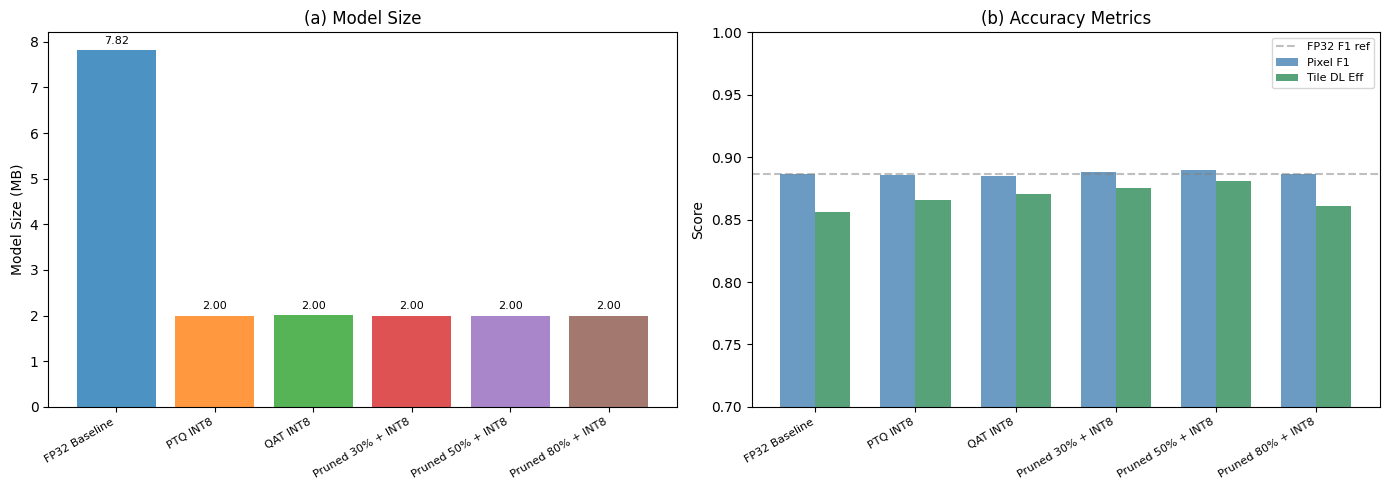

In [21]:
# =====================================================================
# F1 and model size across compression variants
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

names     = [name for name, size, pix, tile in variants]
sizes     = [size for name, size, pix, tile in variants]
f1s       = [pix["F1"]                    for name, size, pix, tile in variants]
tile_fprs = [tile["FPR"]                  for name, size, pix, tile in variants]
dl_effs   = [tile["Downlink_Efficiency"]  for name, size, pix, tile in variants]


x = np.arange(len(names))
colors = plt.cm.tab10.colors[:len(names)]

# (a) Model size
bars = ax1.bar(x, sizes, color=colors, alpha=0.8)
ax1.set_ylabel("Model Size (MB)")
ax1.set_title("(a) Model Size")
ax1.set_xticks(x)
ax1.set_xticklabels(names, rotation=30, ha="right", fontsize=8)
for bar, s in zip(bars, sizes):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f"{s:.2f}", ha="center", va="bottom", fontsize=8)

# (b) Pixel F1 and Tile DL Efficiency
w = 0.35
ax2.bar(x - w/2, f1s, w, label="Pixel F1", color="steelblue", alpha=0.8)
ax2.bar(x + w/2, dl_effs, w, label="Tile DL Eff", color="seagreen", alpha=0.8)
ax2.axhline(fp32_pix["F1"], ls="--", color="gray", alpha=0.5, label="FP32 F1 ref")
ax2.set_ylabel("Score")
ax2.set_title("(b) Accuracy Metrics")
ax2.set_xticks(x)
ax2.set_xticklabels(names, rotation=30, ha="right", fontsize=8)
ax2.set_ylim(0.7, 1.0)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig(str(SO5_DIR / "compression_summary.png"), dpi=150, bbox_inches="tight")
plt.show()

# 15. U-Net Light vs. MobileNetV3 INT8


MobileNetV3-Large U-Net (5.35M params, trained in Notebook B) is quantized
here to INT8 and compared against all U-Net Light variants in order to veryfy if the beahavior is valid with a different backbone.

In [22]:
# =====================================================================
# MobileNetV3-Large U-Net
# =====================================================================
def conv_block(x, filters, dropout_rate=0.2):
    """Two Conv2D + Batch Normalization + ReLU layers with optional dropout."""
    x = tf.keras.layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    if dropout_rate > 0:
        x = tf.keras.layers.Dropout(dropout_rate)(x)

    x = tf.keras.layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    return x


# Target spatial resolutions for encoder skip connections
SKIP_RESOLUTIONS = [256, 128, 64, 32]


def _find_skip_layers(backbone):
    skips = {}
    for layer in backbone.layers:
        out = layer.output
        if hasattr(out, "shape") and len(out.shape) == 4:
            h = out.shape[1]
            if h in SKIP_RESOLUTIONS:
                skips[h] = layer.name      # overwrite keep last
    return skips


def build_mobilenetv3large_unet(input_shape=(512, 512, 13)):

    tf.keras.backend.clear_session()

    inp = tf.keras.Input(shape=input_shape, name="sentinel2_input")

    #  Encoder: MobileNetV3-Large from scratch with 13-band input
    backbone = tf.keras.applications.MobileNetV3Large(
        input_shape=input_shape,
        include_top=False,
        weights=None,                # from scratch
        include_preprocessing=False,
    )

     # Find skip layers first
    skip_map = _find_skip_layers(backbone)

    # Extract skip connections at 4 resolution levels (shape-based lookup)
    skip_outputs = []

    for res in SKIP_RESOLUTIONS:
      layer_name = skip_map[res]
      layer = backbone.get_layer(layer_name)
      skip_outputs.append(layer.output)

    # Multi output encoder model
    encoder = tf.keras.Model(
        inputs=backbone.input,
        outputs=skip_outputs + [backbone.output],  # 4 skips + bottleneck
        name="mobilenetv3large_encoder",
    )

    # Run encoder
    skip1, skip2, skip3, skip4, x = encoder(inp)
    # skip1: 256x256,  skip2: 128x128,  skip3: 64x64,  skip4: 32x32
    # x (bottleneck): 16x16 x 960

    #  Decoder (shared with U-Net Light for  comparison)

    # 16-> 32
    x = tf.keras.layers.UpSampling2D(2, interpolation="bilinear")(x)
    x = tf.keras.layers.Concatenate()([x, skip4])   # 32x32
    x = conv_block(x, 128)

    # 32 -> 64
    x = tf.keras.layers.UpSampling2D(2, interpolation="bilinear")(x)
    x = tf.keras.layers.Concatenate()([x, skip3])   # 64x64
    x = conv_block(x, 64)

    # 64 -> 128
    x = tf.keras.layers.UpSampling2D(2, interpolation="bilinear")(x)
    x = tf.keras.layers.Concatenate()([x, skip2])   # 128x128
    x = conv_block(x, 32)

    # 128 -> 256
    x = tf.keras.layers.UpSampling2D(2, interpolation="bilinear")(x)
    x = tf.keras.layers.Concatenate()([x, skip1])   # 256x256
    x = conv_block(x, 16)

    # 256 -> 512
    x = tf.keras.layers.UpSampling2D(2, interpolation="bilinear")(x)
    x = conv_block(x, 16)

    # Output
    x = tf.keras.layers.Conv2D(1, 1, padding="same", name="logits")(x)
    out = tf.keras.layers.Activation("sigmoid", dtype="float32", name="cloud_prob")(x)

    return tf.keras.Model(inp, out, name="MobileNetV3Large_UNet")

print("MobileNetV3-Large U-Net architecture defined.")

MobileNetV3-Large U-Net architecture defined.


In [23]:
# =====================================================================
# Load MobileNetV3 weights, evaluate FP32, quantize to INT8, evaluate
# =====================================================================
MOBV3_DIR = Path("/content/drive/MyDrive/TFM/MobileNetV3_CloudSEN12_B16/runs_v1")
MOBV3_PATH = str(MOBV3_DIR / "sym_bce" / "best.keras")

print("Loading MobileNetV3 Strategy A (symmetric BCE)...")
mobv3_model = build_mobilenetv3large_unet(input_shape=(TARGET_SIZE, TARGET_SIZE, NUM_S2_BANDS))
mobv3_model.load_weights(MOBV3_PATH)
mobv3_params = mobv3_model.count_params()
mobv3_size_fp32 = mobv3_params * 4 / 1e6
print(f"  Architecture: {mobv3_model.name}")
print(f"  Parameters:   {mobv3_params:,}")
print(f"  FP32 size:    {mobv3_size_fp32:.2f} MB")

# --- FP32 baseline ---
print("Evaluating MobileNetV3 FP32 on TEST set...")
mobv3_fp32_pix = evaluate_pixel_level(mobv3_model, test_ds, t_pix=0.5)
mobv3_fp32_tile = evaluate_tile_level(mobv3_model, test_ds, t_pix=0.5, t_img=0.70)
print(f"  Pixel — F1={mobv3_fp32_pix["F1"]:.4f}  FPR={mobv3_fp32_pix["FPR"]:.4f}  Recall={mobv3_fp32_pix["Recall"]:.4f}")
print(f"  Tile  — FPR={mobv3_fp32_tile["FPR"]:.4f}  DL Eff={mobv3_fp32_tile["Downlink_Efficiency"]:.4f}")

# --- PTQ INT8 ---
print("\nConverting MobileNetV3 to INT8 (PTQ)...")
converter_mv3 = tf.lite.TFLiteConverter.from_keras_model(mobv3_model)
converter_mv3.optimizations = [tf.lite.Optimize.DEFAULT]
converter_mv3.representative_dataset = calibration_generator
converter_mv3.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_mv3.inference_input_type = tf.float32
converter_mv3.inference_output_type = tf.float32
tflite_mv3 = converter_mv3.convert()

mv3_tflite_path = str(SO5_DIR / "mobilenetv3_ptq_int8.tflite")
with open(mv3_tflite_path, "wb") as f:
    f.write(tflite_mv3)
mv3_int8_size = len(tflite_mv3) / 1e6
print(f"  Saved: {mv3_tflite_path}")
print(f"  INT8 size: {mv3_int8_size:.2f} MB (compression: {mobv3_size_fp32/mv3_int8_size:.1f}×)")

del mobv3_model
gc.collect()

# --- INT8 evaluation ---
print("\nEvaluating MobileNetV3 INT8 on TEST set...")
interp_mv3 = tf.lite.Interpreter(model_path=mv3_tflite_path)
interp_mv3.allocate_tensors()
mobv3_int8_pix = evaluate_tflite_pixel(interp_mv3, test_ds, t_pix=0.5)
mobv3_int8_tile = evaluate_tflite_tile(interp_mv3, test_ds, t_pix=0.5, t_img=0.70)
print(f"  Pixel — F1={mobv3_int8_pix["F1"]:.4f}  FPR={mobv3_int8_pix["FPR"]:.4f}  Recall={mobv3_int8_pix["Recall"]:.4f}")
print(f"  Tile  — FPR={mobv3_int8_tile["FPR"]:.4f}  DL Eff={mobv3_int8_tile["Downlink_Efficiency"]:.4f}")

print(f"\n{'='*60}")
print(f"  MobileNetV3 INT8 vs U-Net Light FP32")
print(f"{'='*60}")
print(f"  Size:     {mv3_int8_size:.2f} MB vs {baseline_size_mb:.2f} MB ({"smaller" if mv3_int8_size < baseline_size_mb else "larger"})")
print(f"  Pix F1:   {mobv3_int8_pix["F1"]:.4f} vs {fp32_pix["F1"]:.4f} (Δ={mobv3_int8_pix["F1"]-fp32_pix["F1"]:+.4f})")
print(f"  Tile FPR: {mobv3_int8_tile["FPR"]:.4f} vs {fp32_tile["FPR"]:.4f}")
print(f"  DL Eff:   {mobv3_int8_tile["Downlink_Efficiency"]:.4f} vs {fp32_tile["Downlink_Efficiency"]:.4f}")

Loading MobileNetV3 Strategy A (symmetric BCE)...
  Architecture: MobileNetV3Large_UNet
  Parameters:   5,345,329
  FP32 size:    21.38 MB
Evaluating MobileNetV3 FP32 on TEST set...
  Pixel — F1=0.9132  FPR=0.0536  Recall=0.9123
  Tile  — FPR=0.0527  DL Eff=0.8905

Converting MobileNetV3 to INT8 (PTQ)...


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


  Saved: /content/drive/MyDrive/TFM/UNet_Light_CloudSEN12_B16/so5a_deployment_v1_1/mobilenetv3_ptq_int8.tflite
  INT8 size: 5.86 MB (compression: 3.7×)

Evaluating MobileNetV3 INT8 on TEST set...


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


  Pixel — F1=0.9013  FPR=0.0562  Recall=0.8941
  Tile  — FPR=0.0474  DL Eff=0.8607

  MobileNetV3 INT8 vs U-Net Light FP32
  Size:     5.86 MB vs 7.82 MB (smaller)
  Pix F1:   0.9013 vs 0.8869 (Δ=+0.0145)
  Tile FPR: 0.0474 vs 0.0474
  DL Eff:   0.8607 vs 0.8557


# 16. ROC Curves

Threshold sweep across the full operating range

In [ ]:
# =====================================================================
# Streaming ROC sweep — multi-operational point evaluation
# =====================================================================
THRESHOLDS = np.concatenate([
    [0.001, 0.005, 0.01, 0.02],
    np.arange(0.05, 0.96, 0.025),
    [0.96, 0.98, 0.99, 0.995, 0.999],
])
T_IMG = 0.70
N_THR = len(THRESHOLDS)

def _sweep_core(ds, predict_fn):
    """Core sweep logic shared by FP32 and TFLite variants."""
    pix_TP = np.zeros(N_THR); pix_FP = np.zeros(N_THR)
    pix_TN = np.zeros(N_THR); pix_FN = np.zeros(N_THR)
    tile_TP = np.zeros(N_THR); tile_FP = np.zeros(N_THR)
    tile_TN = np.zeros(N_THR); tile_FN = np.zeros(N_THR)

    for xb, yb in ds:
        yb_np = yb.numpy()
        for i in range(xb.shape[0]):
            prob = predict_fn(xb[i:i+1])
            y = yb_np[i, :, :, 0]
            valid = (y != IGNORE_LABEL)
            y_v = y[valid]
            p_v = prob[valid]
            gt_cf = y_v.mean()
            gt_tile = int(gt_cf >= T_IMG)
            p_row = p_v[np.newaxis, :]
            t_col = THRESHOLDS[:, np.newaxis]
            pred_mask = (p_row >= t_col)
            gt_cloud = (y_v == 1)
            gt_clear = (y_v == 0)
            pix_TP += np.sum(pred_mask & gt_cloud, axis=1)
            pix_FP += np.sum(pred_mask & gt_clear, axis=1)
            pix_FN += np.sum(~pred_mask & gt_cloud, axis=1)
            pix_TN += np.sum(~pred_mask & gt_clear, axis=1)
            pred_cfs = pred_mask.mean(axis=1)
            pred_tiles = (pred_cfs >= T_IMG).astype(int)
            for j in range(N_THR):
                pt = pred_tiles[j]
                if   gt_tile == 1 and pt == 1: tile_TP[j] += 1
                elif gt_tile == 0 and pt == 1: tile_FP[j] += 1
                elif gt_tile == 1 and pt == 0: tile_FN[j] += 1
                else:                          tile_TN[j] += 1
    eps = 1e-8
    pix = [{"t_pix": THRESHOLDS[j],
            "FPR": pix_FP[j]/(pix_FP[j]+pix_TN[j]+eps),
            "Rec": pix_TP[j]/(pix_TP[j]+pix_FN[j]+eps),
            "F1":  2*pix_TP[j]/(2*pix_TP[j]+pix_FP[j]+pix_FN[j]+eps)}
           for j in range(N_THR)]
    tile = [{"t_pix": THRESHOLDS[j],
             "FPR": tile_FP[j]/(tile_FP[j]+tile_TN[j]+eps),
             "Downlink_Efficiency":  tile_TP[j]/(tile_TP[j]+tile_FN[j]+eps)}
            for j in range(N_THR)]
    return pix, tile

def sweep_keras(model, ds):
    def pred(x): return model(x, training=False).numpy()[0,:,:,0]
    return _sweep_core(ds, pred)

def sweep_tflite(path, ds):
    interp = tf.lite.Interpreter(model_path=path)
    interp.allocate_tensors()
    inp_d = interp.get_input_details()[0]
    out_d = interp.get_output_details()[0]
    def pred(x):
        interp.set_tensor(inp_d['index'], x.numpy())
        interp.invoke()
        return interp.get_tensor(out_d['index'])[0,:,:,0]
    return _sweep_core(ds, pred)

print(f"Sweep functions defined. {N_THR}")

In [ ]:
# =====================================================================
# Run ROC sweeps
# =====================================================================
roc = {}

print("U-Net Light FP32...")
mdl = build_unet_light(input_shape=(TARGET_SIZE, TARGET_SIZE, NUM_S2_BANDS))
mdl.load_weights(BASELINE_PATH)
roc["UNet-L FP32\n(7.82 MB)"] = sweep_keras(mdl, test_ds)
del mdl; gc.collect()

print("U-Net Light PTQ INT8...")
roc["UNet-L PTQ INT8\n({:.2f} MB)"] = sweep_tflite(ptq_path, test_ds)

print("MobileNetV3 FP32...")
mdl = build_mobilenetv3large_unet(input_shape=(TARGET_SIZE, TARGET_SIZE, NUM_S2_BANDS))
mdl.load_weights(MOBV3_PATH)
roc["MobV3 FP32\n({:.1f} MB)".format(mobv3_size_fp32)] = sweep_keras(mdl, test_ds)
del mdl; gc.collect()

print("MobileNetV3 INT8...")
roc["MobV3 INT8\n({:.2f} MB)".format(mv3_int8_size)] = sweep_tflite(mv3_tflite_path, test_ds)

print("\nAll sweeps complete.")

In [ ]:
# =====================================================================
# Pixel-level AUROC
# =====================================================================
def pixel_auroc(pix_sweep, recall_key="Rec"):
    """AUROC from a pixel-level threshold sweep.
    Takes ROC points from the sweep, sorts them by FPR,
    removes duplicate FPR values by keeping the best TPR,
    adds the endpoints (0,0) and (1,1) if missing,
    computes the area under the curve with trapezoidal integration."""
    fpr = np.array([r["FPR"]       for r in pix_sweep], dtype=float)
    tpr = np.array([r[recall_key]  for r in pix_sweep], dtype=float)

    order = np.argsort(fpr)
    fpr, tpr = fpr[order], tpr[order]

    fpr_u, tpr_u = [], []
    for x in np.unique(fpr):
        fpr_u.append(x)
        tpr_u.append(tpr[fpr == x].max())
    fpr_u = np.array(fpr_u, dtype=float)
    tpr_u = np.array(tpr_u, dtype=float)

    if fpr_u[0] > 0:
        fpr_u = np.insert(fpr_u, 0, 0.0); tpr_u = np.insert(tpr_u, 0, 0.0)
    if fpr_u[-1] < 1:
        fpr_u = np.append(fpr_u, 1.0);    tpr_u = np.append(tpr_u, 1.0)

    return float(np.trapezoid(tpr_u, fpr_u))

# Compute AUROC for each model variant
test_auroc = {name: pixel_auroc(roc[name][0]) for name in roc.keys()}

print(f"{'Model':<35} {'Test AUROC':>11}")
print("-" * 50)
for name, auc in test_auroc.items():
    print(f"{name.replace(chr(10), ' '):<35} {auc:>11.4f}")

# Save
import json as _json
with open(SO5_DIR / "auroc_summary_deployment.json", "w") as f:
    _json.dump(test_auroc, f, indent=2)
print(f"\nSaved: {SO5_DIR / 'auroc_summary_deployment.json'}")


ecall at fixed Pixel FPR ~ 5% :
  UNet-L FP32 (7.82 MB)         : Recall=0.8547 at FPR=0.0500
  UNet-L PTQ INT8 ({:.2f} MB)   : Recall=0.8509 at FPR=0.0496
  MobV3 FP32 (21.4 MB)          : Recall=0.9070 at FPR=0.0502
  MobV3 INT8 (5.86 MB)          : Recall=0.8833 at FPR=0.0493


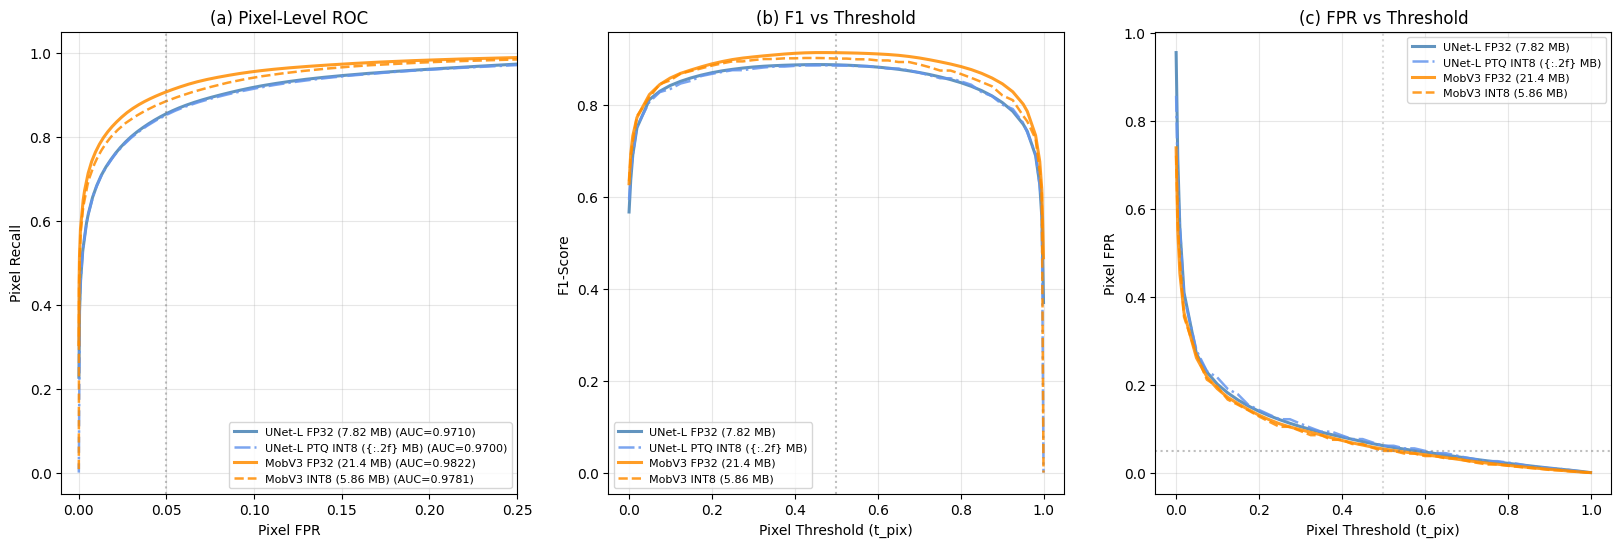

In [27]:
# =====================================================================
#  ROC — 3 panels
# =====================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

style_map = {
    0: {"color": "steelblue",    "ls": "-",  "lw": 2.2},    # UNet FP32
    1: {"color": "cornflowerblue", "ls": "-.", "lw": 1.8},  # UNet PTQ
    2: {"color": "darkorange",   "ls": "-",  "lw": 2.2},    # MobV3 FP32
    3: {"color": "darkorange",   "ls": "--", "lw": 1.8},    # MobV3 INT8
}


names = list(roc.keys())

# (a) Pixel ROC
ax = axes[0]
ax = axes[0]

for idx, name in enumerate(names):
    pix, tile = roc[name]
    s = style_map[idx]

    fpr_values    = [p["FPR"] for p in pix]
    recall_values = [p["Rec"] for p in pix]
    auc_label = f"{name.replace(chr(10), ' ')} (AUC={test_auroc[name]:.4f})"
    ax.plot(fpr_values, recall_values,
            color=s["color"], ls=s["ls"], lw=s["lw"],
            label=auc_label, alpha=0.85)
ax.axvline(0.05, ls=":", color="gray", alpha=0.5)
ax.set_xlabel("Pixel FPR")
ax.set_ylabel("Pixel Recall")
ax.set_title("(a) Pixel-Level ROC")
ax.legend(fontsize=8, loc="lower right")
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.01, 0.25)

# (b) F1 vs threshold
ax = axes[1]
for idx, name in enumerate(names):
    pix, tile = roc[name]
    s = style_map[idx]

    threshold_values = [p["t_pix"] for p in pix]
    f1_values        = [p["F1"]    for p in pix]

    ax.plot(threshold_values, f1_values,
            color=s["color"], ls=s["ls"], lw=s["lw"],
            label=name.replace("\n", " "), alpha=0.85)
ax.axvline(0.5, ls=":", color="gray", alpha=0.5)
ax.set_xlabel("Pixel Threshold (t_pix)")
ax.set_ylabel("F1-Score")
ax.set_title("(b) F1 vs Threshold")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# (c) FPR vs Threshold
ax = axes[2]
for idx, name in enumerate(names):
    pix, tile = roc[name]
    s = style_map[idx]
    threshold_values = [p["t_pix"] for p in pix]
    fpr_values       = [p["FPR"]   for p in pix]
    ax.plot(threshold_values, fpr_values,
            color=s["color"], ls=s["ls"], lw=s["lw"],
            label=name.replace("\n", " "), alpha=0.85)

ax.axhline(0.05, ls=":", color="gray", alpha=0.5)
ax.axvline(0.5, ls=":", color="gray", alpha=0.3)
ax.set_xlabel("Pixel Threshold (t_pix)")
ax.set_ylabel("Pixel FPR")
ax.set_title("(c) FPR vs Threshold")
ax.legend(fontsize=8, loc="upper right")
ax.grid(True, alpha=0.3)

# Print  check
print("\necall at fixed Pixel FPR ~ 5% :")
for name in names:
    pix, _ = roc[name]
    r5 = min(pix, key=lambda p: abs(p["FPR"] - 0.05))
    print(f"  {name.replace(chr(10),' '):30s}: Recall={r5['Rec']:.4f} at FPR={r5['FPR']:.4f}")